# Prior vs UCB in Gaussian Processes Regression

**Notation**: Given are GPs with mean function $\mu(x)$, covariance function $k(x, x')$ and data $D = \{x_i\}_{i=1}^n$ and $\mathbf{y}_D = \{y_i\}_{i=1}^n$. The covariance function is also written as 

$$
\mathbf{k}(x, D) = \begin{bmatrix}k(x, x_1) \\
\vdots \\
k(x, x_n)\end{bmatrix} \quad \text{and} \quad K(D, D) = \begin{bmatrix}k(x_1, x_1) & \cdots & k(x_1, x_n) \\
\vdots & \ddots & \vdots \\
k(x_n, x_1) & \cdots & k(x_n, x_n)\end{bmatrix}.
$$

Setting a high mean and doing a “greedy” highest-expectation search, i.e. $\max_x \mu'_p(x\mid \mu=\mu_0)$, is closely related to maximizing a UCB-style acquisition $\max_x \mu'(x\mid \mu\equiv 0)+\beta\,\sigma'^2(x)$ in the GP setting.

Using the notation from above, the GP posterior mean for a mean function $\mu$ is
$$
\mu'(x\mid \mu)=\mu(x)+\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\bigl(\mathbf{y}_D-\mu(D)\bigr),
$$
and the posterior variance (independent of $\mu$) is
$$
\sigma'^2(x)=k(x,x)-\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D).
$$

So the UCB acquisition with zero mean and confidence parameter $\beta$ can be written as
$$
\mu'(x\mid \mu = 0)+\beta\,\sigma'^2(x)
=\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{y}_D
\;\; +\beta\,k(x,x)-\beta\,\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D).
$$

Whereas the posterior mean under a nonzero mean $\mu_0$ can be written as
$$
\mu'_p(x\mid \mu=\mu_0)
=\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{y}_D
\;\; +\mu_0(x)-\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mu_0(D).
$$

Comparing the last terms suggests the heuristic identification
$$
\mu_0(x)\approx \beta\,k(x,x)
\quad\text{and}\quad
\mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\mathbf{k}(x,D)
\approx \mathbf{k}(x,D)^T\bigl(K(D,D)+\sigma_n^2 I\bigr)^{-1}\operatorname{diag}\bigl(K(D,D)\bigr),
$$
i.e. setting $\mu_0(x_i)=\beta\,k(x_i,x_i)$ on the observed inputs makes “greedy” maximization under $\mu_0$ behave similarly to UCB.

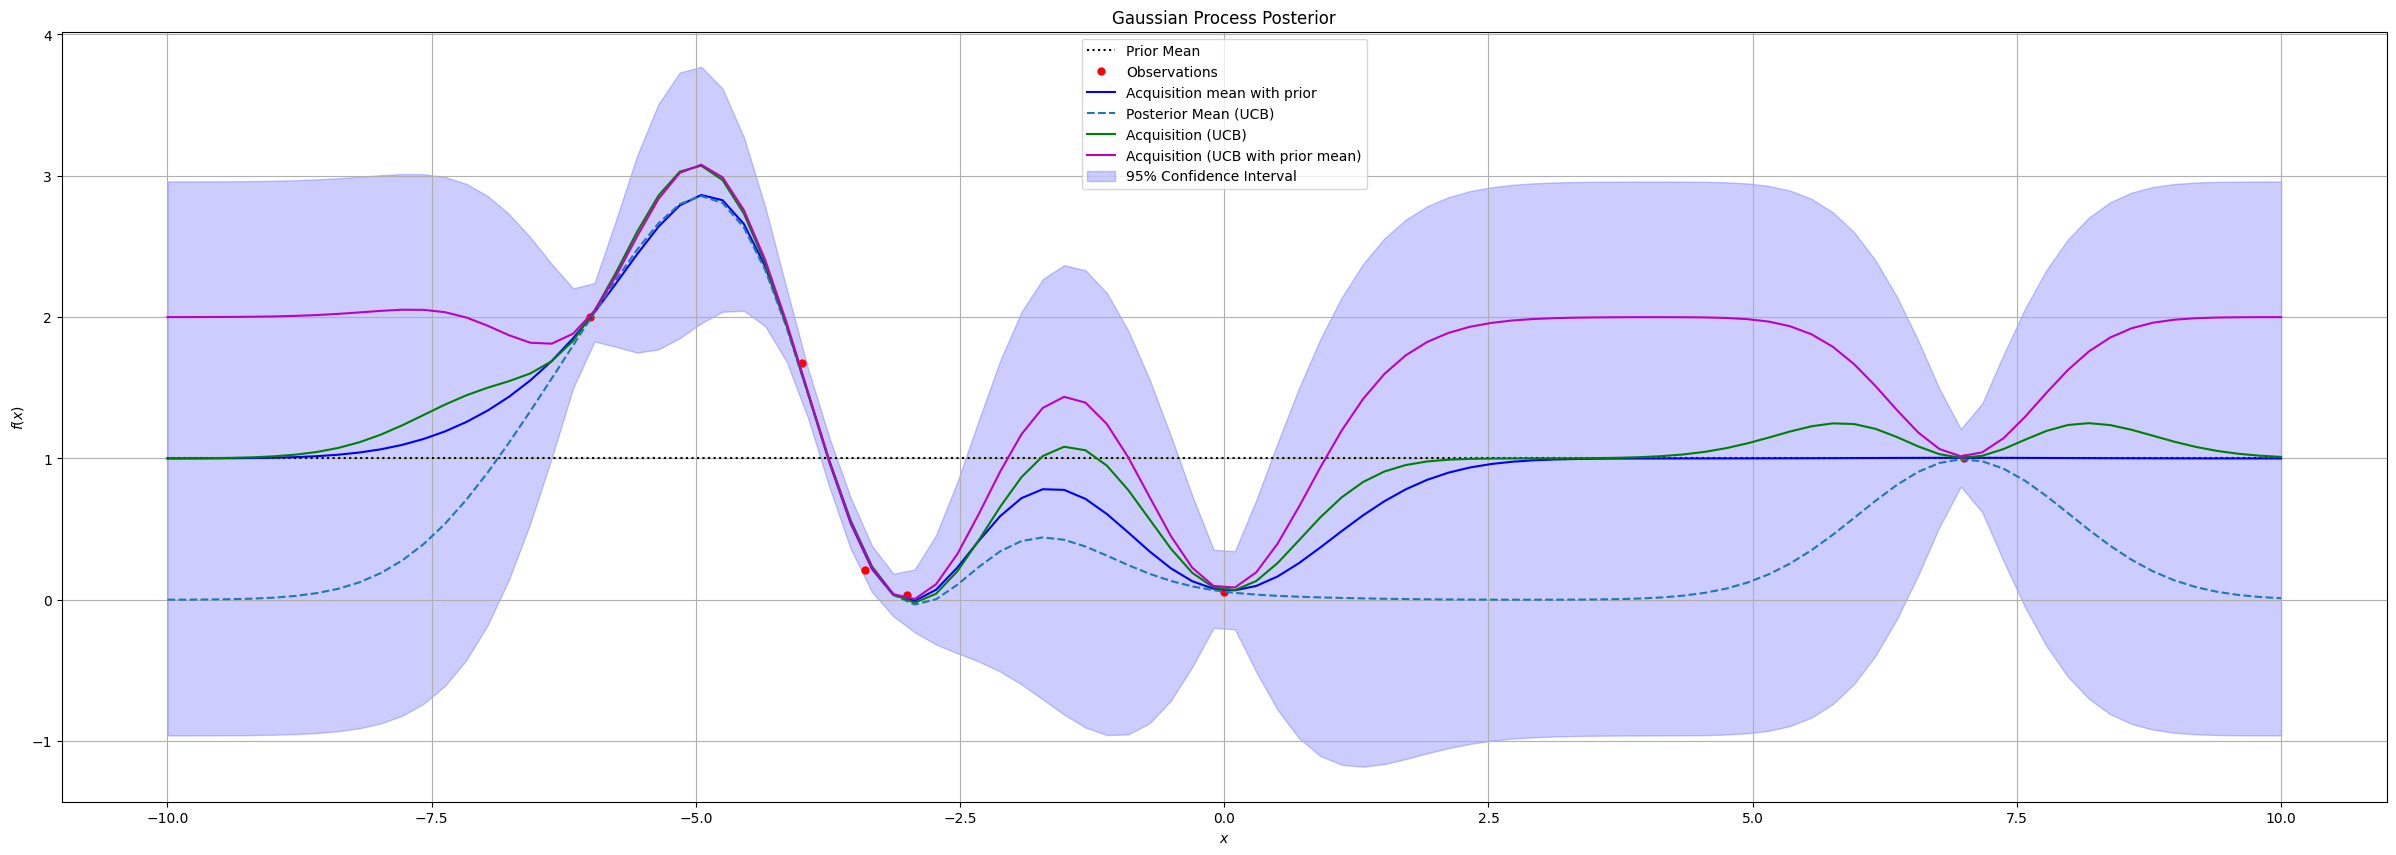

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Custom RBF Kernel implementation
class RBF:
    def __init__(self, length_scale=1.0, length_scale_bounds="fixed"):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds
    
    def __call__(self, X1, X2):
        """Compute the RBF kernel between X1 and X2"""
        # Compute squared Euclidean distance between each pair of points
        X1 = np.atleast_2d(X1)
        X2 = np.atleast_2d(X2)
        
        # Calculate distance matrix
        dists = np.sum(X1**2, axis=1)[:, np.newaxis] + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        
        # Apply RBF kernel formula: K(x,y) = exp(-||x-y||^2 / (2*l^2))
        return np.exp(-dists / (2 * self.length_scale**2))

# Gaussian Process Regressor implementation
class GaussianProcessRegressor:
    def __init__(self, mean=None, kernel=None, alpha=1e-10, n_restarts_optimizer=0):
        self.mean = mean
        self.kernel = kernel if kernel is not None else RBF()
        self.alpha = alpha  # Noise level
        self.X_train = None
        self.y_train = None
        self.K_inv = None
        self.n_restarts_optimizer = n_restarts_optimizer

    def fit(self, X, y):
        """Fit Gaussian Process Regression model"""
        self.X_train = np.atleast_2d(X)
        self.y_train = np.atleast_1d(y)

        # Compute kernel matrix
        K = self.kernel(self.X_train, self.X_train)

        # Add noise to diagonal
        K_noisy = K + self.alpha * np.eye(len(self.X_train))

        # Compute inverse of kernel matrix
        self.K_inv = np.linalg.inv(K_noisy)
        return self

    def predict(self, X, return_std=False):
        """Predict using the Gaussian Process model"""
        X = np.atleast_2d(X)

        # Compute covariance between training and test points
        K_trans = self.kernel(X, self.X_train)

        # Compute mean prediction
        mean_X = self.mean(X) if self.mean is not None else np.zeros(X.shape[0])
        mean_train = self.mean(self.X_train) if self.mean is not None else np.zeros_like(self.y_train)
        y_mean = K_trans @ self.K_inv @ (self.y_train - mean_train) + mean_X

        if not return_std:
            return y_mean

        # Compute variance/standard deviation if requested
        K_test = self.kernel(X, X)
        y_var = K_test - K_trans @ self.K_inv @ K_trans.T
        # Extract diagonal elements for point-wise variances
        y_var = np.diag(y_var)
        y_var = np.maximum(y_var, 0)  # Ensure positive variance

        return y_mean, np.sqrt(y_var)

# --- Configuration ---
# Prior mean function (can be any callable)
def prior_mean_func(x):
    return np.ones(len(x))

# Define kernel
kernel = RBF(length_scale=1.0, length_scale_bounds="fixed")

# Observations
X_obs = np.array([-4, -3.4, -3, 0, 7, -6]).reshape(-1, 1)
y_obs = np.array([1.67268999, 0.20988119, 0.03688849, 0.05757694, 1.00456709, 2.])

# Observation noise level (added to the diagonal of the kernel matrix)
noise_level = 1e-1

# Points for prediction and plotting
X_plot = np.linspace(-10, 10, 100).reshape(-1, 1)
# ---

# Create and fit the Gaussian Process Regressor
prior_gp = GaussianProcessRegressor(mean=prior_mean_func, kernel=kernel, alpha=noise_level**2)
# Ensure y is 1D for fitting
prior_gp.fit(X_obs, y_obs) # Fit on data centered around prior

ucb_gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_level**2)
ucb_gp.fit(X_obs, y_obs)

# Make predictions
# Predictions and std deviation will now be 1D
y_pred, sigma = prior_gp.predict(X_plot, return_std=True)
y_mean_ucb, sigma_ucb = ucb_gp.predict(X_plot, return_std=True)

beta = 1.0
y_pred_ucb = y_mean_ucb + beta * sigma_ucb ** 2
y_pred_ucb_prior = y_pred + beta * sigma ** 2

# --- Visualization ---
plt.figure(figsize=(30, 10))

# Plot Prior Mean
plt.plot(X_plot, prior_mean_func(X_plot).ravel(), 'k:', label='Prior Mean')

# Plot Observations
plt.plot(X_obs, y_obs, 'r.', markersize=10, label='Observations')

# Plot Posterior Mean
plt.plot(X_plot, y_pred, "b-", label="Acquisition mean with prior")
plt.plot(X_plot, y_mean_ucb, "--", label="Posterior Mean (UCB)")
plt.plot(X_plot, y_pred_ucb, 'g-', label='Acquisition (UCB)')
plt.plot(X_plot, y_pred_ucb_prior, 'm-', label='Acquisition (UCB with prior mean)')

# Plot Confidence Interval
plt.fill_between(X_plot.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma,
                 alpha=0.2, color='blue', label='95% Confidence Interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Gaussian Process Posterior')
plt.legend()
plt.grid(True)
plt.show()

## The two models used below

### Model 1 (1D Gaussian process regression)
We assume an unknown real-valued function $f(x)$ on $\mathbb{R}$ and noisy observations
$$
 y_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\sigma_n^2).
$$
A Gaussian process prior specifies that for any finite set of inputs, the vector of function values is jointly Gaussian:
$$
 f \sim \mathcal{GP}(\mu, k).
$$
In the code we use an RBF kernel (a.k.a. squared exponential)
$$
 k(x,x') = \exp\!\left(-\tfrac{\|x-x'\|^2}{2\ell^2}\right),
$$
with a user-chosen noise level $\sigma_n$.

- **Posterior**: conditioning the GP prior on $(D,\mathbf{y}_D)$ gives the standard closed-form posterior mean $\mu'(x)$ and variance $\sigma'^2(x)$ (as written above).
- **UCB**: a typical Bayesian-optimization acquisition is an *upper confidence bound* such as $a_{\text{UCB}}(x)=\mu'(x)+\kappa\,\sigma'(x)$ (or the variant $\mu'(x)+\beta\,\sigma'^2(x)$ used in the derivation section).
- **High prior mean vs UCB**: if you choose a nonzero prior mean $\mu_0(x)$ and then act “greedily” (maximize the posterior mean under that prior), this can resemble a UCB objective because both can be expanded into a shared data-fit term plus a term that rewards “optimism” (via either the prior mean or posterior uncertainty).

**How is UCB optimized in practice?** The acquisition $a_{\text{UCB}}(x)$ is usually *non-convex*, so it’s commonly optimized by:
- **Gradient-based ascent with box constraints + multiple restarts** (e.g. L-BFGS-B / projected gradient), when $k$ is differentiable and $x$ is continuous.
- **Derivative-free optimizers** (CMA-ES, DIRECT, random search), when gradients are inconvenient or the domain has discrete/mixed variables.
- A coarse **candidate/grid search** is mostly for low-dimensional demos.

### Model 2 (2D latent GP + sigmoid = GP classification, Laplace approximation)
Here the outcome is *binary* (success/failure), so we model a success probability surface
$$
 p(x)=\mathbb{P}(y=1\mid x), \qquad x\in\mathbb{R}^2.
$$

**Latent GP model.** We introduce a latent real-valued function $f(x)$ and a logistic link:
- Prior: $f \sim \mathcal{GP}(m, k)$ (in the toy code, $m(x)$ is a constant and $k$ is an RBF kernel).
- Likelihood: $y_i\mid f(x_i) \sim \mathrm{Bernoulli}(\sigma(f(x_i)))$ with $\sigma(z)=1/(1+e^{-z})$.

**MAP and Laplace approximation.** With a logistic likelihood the posterior is not Gaussian, so neither the posterior nor the MAP has a closed form. We compute the MAP values
$$
\hat f = \arg\max_f \; \log p(f\mid y)
$$
by Newton’s method on the finite-dimensional vector $f(X)=(f(x_1),\dots,f(x_n))$, and then approximate
$$
 p(f(X)\mid y) \approx \mathcal{N}(\hat f,\,\Sigma),
 \qquad \Sigma = (K^{-1}+W)^{-1},\; W=\mathrm{diag}(\sigma(\hat f_i)(1-\sigma(\hat f_i))).
$$

**Approximate UCB vs “optimistic MAP prior”.** From the Laplace state we get an approximate posterior mean/variance for the latent $f(x)$:
- **Approx-UCB** (latent): $a_{\text{UCB}}(x)=\mu_f(x)+\kappa\sqrt{v_f(x)}$ (and we optionally apply $\sigma(\cdot)$ for visualization).
- **MAP with optimistic prior**: set the GP mean to a constant corresponding to $p=0.95$ everywhere, i.e. $m(x)\equiv\mathrm{logit}(0.95)$, and then choose points by maximizing the plug-in posterior mean $\mu_f(x)$ (equivalently $\sigma(\mu_f(x))$ since $\sigma$ is monotone).

**How we maximize the acquisitions here.** The next point is chosen by *continuous* optimization in $x$ (not a discrete grid argmax): projected gradient ascent with random restarts. The gradients are analytic because the RBF kernel is differentiable (we differentiate $k(x,X)$ with respect to $x$).

**Visualization in the final figure.** In each panel:
- **Hue** encodes the *true* success probability $p_{\text{true}}(x)$ (this is not a density; its maximum is $\le 1$).
- **Brightness** encodes the method’s acquisition value (UCB on the left, MAP on the right).
- The trajectory shows which $x$ values were queried over time.

true success probability at hot spot (np.float64(1.5), np.float64(1.5)): 0.9500 (global maximum)
max true success probability on plotting grid: 0.9500
MAP prior-mean success probability: max |p-0.95| over grid = 1.11e-16
best true success prob among chosen (UCB): 0.9480
best true success prob among chosen (MAP): 0.9196
observed success rate (UCB): 0.434 (n=53)
observed success rate (MAP): 0.642 (n=53)
UCB latent ranges: mu in [-0.949, 1.406], v in [0.218, 0.870]


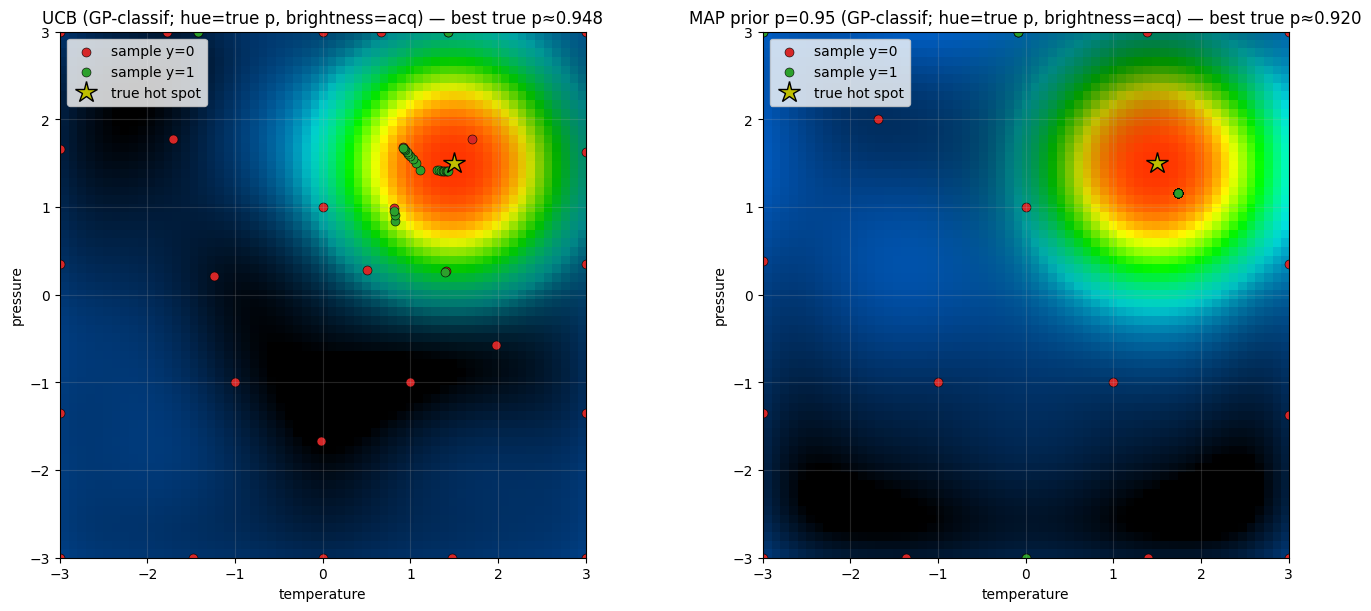

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Applied toy example (2D, non-Gaussian likelihood) ---
# Imagine a manufacturing process where you can choose two control settings x = (temperature, pressure).
# Each run returns a binary outcome: y=1 means "defect-free", y=0 means "defective".
# We want to find settings that maximize the success probability with as few trials as possible.
#
# Model (this cell): GP classification
#   f ~ GP(m(x), k(x,x'))
#   y | f(x) ~ Bernoulli(sigmoid(f(x)))
#
# Key point: with a logistic link, the posterior is NOT Gaussian, so the MAP is not closed-form.
# We compute it via a Laplace approximation (Newton iterations), and then we can compute
# acquisition values and their gradients w.r.t. x analytically (because the RBF kernel is differentiable).


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def logit(p):
    p = np.asarray(p)
    return np.log(p / (1.0 - p))


def rbf_kernel(X1, X2, length_scale, variance=1.0):
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    diffs = X1[:, None, :] - X2[None, :, :]
    sqdist = np.sum(diffs**2, axis=-1)
    return variance * np.exp(-0.5 * sqdist / (length_scale**2))


def rbf_kernel_grad_x(x, X_train, length_scale, variance=1.0):
    """Gradient wrt x of k(x, X_train): returns (n,2)."""
    x = np.asarray(x, dtype=float).reshape(1, 2)
    X_train = np.atleast_2d(X_train)
    diffs = X_train - x  # (n,2) == (x_i - x)
    k = rbf_kernel(x, X_train, length_scale, variance=variance).reshape(-1)  # (n,)
    return (k[:, None] * diffs) / (length_scale**2)


def maximize_with_restarts(f_and_grad, bounds, rng, n_restarts=25, n_steps=200, step0=0.25):
    """Projected gradient ascent with backtracking and random restarts.

    f_and_grad(x) -> (f, grad) where grad is w.r.t. x in R^2.
    """
    lows = np.array([b[0] for b in bounds], dtype=float)
    highs = np.array([b[1] for b in bounds], dtype=float)

    best_x = None
    best_f = -np.inf

    for _ in range(n_restarts):
        x = rng.uniform(lows, highs)
        step = step0

        for _ in range(n_steps):
            f, g = f_and_grad(x)
            if not (np.isfinite(f) and np.all(np.isfinite(g))):
                break
            g_norm = float(np.linalg.norm(g))
            if g_norm < 1e-10:
                break

            # Take a normalized gradient step + projection
            x_new = x + step * (g / (g_norm + 1e-12))
            x_new = np.minimum(np.maximum(x_new, lows), highs)

            f_new, _ = f_and_grad(x_new)
            if np.isfinite(f_new) and (f_new >= f):
                x = x_new
                step *= 1.02
            else:
                step *= 0.5
                if step < 1e-6:
                    break

        f_final, _ = f_and_grad(x)
        if f_final > best_f:
            best_f = float(f_final)
            best_x = x.copy()

    return best_x, best_f


def fit_laplace_gp_classification(
    X,
    y,
    mean_const,
    length_scale,
    variance=1.0,
    jitter=1e-6,
    max_iter=30,
    tol=1e-7,
):
    """Laplace approximation for GP classification with logistic likelihood.

    Prior: f ~ N(m, K) where m is a constant mean.
    Likelihood: p(y_i=1|f_i)=sigmoid(f_i).

    Returns a dict with the MAP f and cached matrices for fast prediction/gradients.
    """
    X = np.atleast_2d(X)
    y = y.astype(float).reshape(-1)
    n = X.shape[0]

    K = rbf_kernel(X, X, length_scale, variance=variance)
    K = K + jitter * np.eye(n)

    cholK = np.linalg.cholesky(K)

    def solveK(v):
        return np.linalg.solve(cholK.T, np.linalg.solve(cholK, v))

    K_inv = solveK(np.eye(n))
    m_vec = mean_const * np.ones(n)

    # Initialize at the prior mean
    f = m_vec.copy()

    for _ in range(max_iter):
        p = sigmoid(f)
        W = p * (1.0 - p)  # diag entries

        # grad log posterior: y-p - K^{-1}(f-m)
        g = (y - p) - (K_inv @ (f - m_vec))

        # Hessian of negative log posterior: K^{-1} + W
        P = K_inv + np.diag(W)

        # Newton step for maximizing log posterior
        step = np.linalg.solve(P, g)
        f_new = f + step

        if np.max(np.abs(step)) < tol:
            f = f_new
            break
        f = f_new

    # Final W and posterior covariance (Laplace): Sigma = (K^{-1} + W)^{-1}
    p = sigmoid(f)
    W = p * (1.0 - p)
    P = K_inv + np.diag(W)
    Sigma = np.linalg.solve(P, np.eye(n))

    # Cache for prediction: mu(x)=m + k(x,X)^T alpha where alpha = K^{-1}(f-m)
    alpha = K_inv @ (f - m_vec)

    # Cache for variance: v(x)=k(x,x) - k^T A k, where A = K^{-1} - K^{-1} Sigma K^{-1}
    A = K_inv - K_inv @ Sigma @ K_inv
    A = 0.5 * (A + A.T)

    return {
        "X": X,
        "y": y,
        "mean_const": float(mean_const),
        "length_scale": float(length_scale),
        "variance": float(variance),
        "K": K,
        "K_inv": K_inv,
        "f_map": f,
        "W": W,
        "Sigma": Sigma,
        "alpha": alpha,
        "A": A,
    }


def predict_latent_and_grads(model, x):
    """Return (mu, v, grad_mu, grad_v) for the latent f(x) under Laplace GP classification."""
    x = np.asarray(x, dtype=float).reshape(2,)
    X = model["X"]
    mean_const = model["mean_const"]
    ls = model["length_scale"]
    var = model["variance"]

    k = rbf_kernel(x.reshape(1, 2), X, ls, variance=var).reshape(-1)  # (n,)
    dk = rbf_kernel_grad_x(x, X, ls, variance=var)  # (n,2)

    alpha = model["alpha"]
    A = model["A"]

    mu = mean_const + float(k @ alpha)
    grad_mu = dk.T @ alpha  # (2,)

    Ak = A @ k
    v = var - float(k @ Ak)
    # Numerical safety: enforce 0 <= v <= k(x,x)=var for an RBF with fixed variance.
    v = min(max(v, 0.0), var)

    # d/dx (k^T A k) = 2 (dk/dx)^T A k
    grad_v = -2.0 * (dk.T @ Ak)

    return mu, v, grad_mu, grad_v


def make_map_objective_gp(model):
    # Maximize the posterior mean of the latent (sigmoid monotone).
    def f_and_grad(x):
        mu, _, grad_mu, _ = predict_latent_and_grads(model, x)
        return float(mu), grad_mu

    return f_and_grad


def make_ucb_objective_gp(model, kappa=2.0):
    # Maximize mu(x) + kappa * sqrt(v(x)) in latent space.
    def f_and_grad(x):
        mu, v, grad_mu, grad_v = predict_latent_and_grads(model, x)
        s = np.sqrt(v + 1e-12)
        z = mu + kappa * s
        grad_z = grad_mu + kappa * 0.5 * grad_v / s
        return float(z), grad_z

    return f_and_grad


# Domain and plotting grid (only for visualization)
rng = np.random.default_rng(7)
xmin, xmax = -3.0, 3.0
bounds = [(xmin, xmax), (xmin, xmax)]

grid_n = 61
xx, yy = np.meshgrid(np.linspace(xmin, xmax, grid_n), np.linspace(xmin, xmax, grid_n))
X_grid = np.column_stack([xx.ravel(), yy.ravel()])

# True (unknown) success probability surface (still a smooth bump in the logit)
# Note: this is just a synthetic ground truth; it does not have to be a GP sample.
hot_spot = np.array([1.5, 1.5])
true_intercept = -2.0
true_length_scale = 0.9
true_amp = float(logit(0.95) - true_intercept)  # ensures p_true(hot_spot)=0.95 and global max is 0.95

def p_true(X):
    X = np.atleast_2d(X)
    diffs = X - hot_spot[None, :]
    sqdist = np.sum(diffs**2, axis=1)
    eta = true_intercept + true_amp * np.exp(-0.5 * sqdist / (true_length_scale**2))
    return sigmoid(eta)

p_true_grid = p_true(X_grid).reshape(xx.shape)
print(f"true success probability at hot spot {tuple(hot_spot)}: {float(p_true(hot_spot)[0]):.4f} (global maximum)")
print(f"max true success probability on plotting grid: {float(np.max(p_true_grid)):.4f}")

# GP classification hyperparameters (kept simple/fixed)
# (In real BO you'd fit these too, but here we focus on prior mean vs UCB behavior.)
gp_length_scale = 1.0
gp_variance = 1.0

# Two strategies (same kernel; different prior mean functions):
# 1) Approx-UCB (Laplace GP classification) with mean m(x)=0
# 2) MAP with a prior mean success probability 0.95 everywhere => m(x)=logit(0.95)
m0_ucb = 0.0
m0_map = float(logit(0.95))

# Sanity check: MAP prior-mean probability is exactly 0.95 everywhere.
max_dev = float(np.max(np.abs(sigmoid(m0_map) - 0.95)))
print(f"MAP prior-mean success probability: max |p-0.95| over grid = {max_dev:.2e}")

kappa = 2.0

# Initialize each method with a few random trials
n_init = 2
T = 50
X_ucb = np.array([[-1, -1], [1, -1], [0, 1]])
X_map = np.array([[-1, -1], [1, -1], [0, 1]])

def sample_y(X):
    p = p_true(X)
    return (rng.uniform(size=p.shape[0]) < p).astype(float)


y_ucb = sample_y(X_ucb)
y_map = sample_y(X_map)

# Sequential design loop (continuous maximization with analytic gradients)
for _ in range(T):
    model_ucb = fit_laplace_gp_classification(
        X_ucb, y_ucb, m0_ucb, gp_length_scale, variance=gp_variance
    )
    model_map = fit_laplace_gp_classification(
        X_map, y_map, m0_map, gp_length_scale, variance=gp_variance
    )

    ucb_obj = make_ucb_objective_gp(model_ucb, kappa=kappa)
    map_obj = make_map_objective_gp(model_map)

    x_next_ucb, _ = maximize_with_restarts(ucb_obj, bounds, rng)
    x_next_map, _ = maximize_with_restarts(map_obj, bounds, rng)

    X_ucb = np.vstack([X_ucb, x_next_ucb])
    y_ucb = np.append(y_ucb, sample_y(x_next_ucb.reshape(1, 2))[0])

    X_map = np.vstack([X_map, x_next_map])
    y_map = np.append(y_map, sample_y(x_next_map.reshape(1, 2))[0])

# Fit one last time to visualize final acquisition surfaces (evaluated on grid for plotting)
model_ucb_final = fit_laplace_gp_classification(
    X_ucb, y_ucb, m0_ucb, gp_length_scale, variance=gp_variance
)
model_map_final = fit_laplace_gp_classification(
    X_map, y_map, m0_map, gp_length_scale, variance=gp_variance
)

# For plotting, evaluate acquisitions on a grid.

def latent_mu_var_on_grid(model, X_test):
    X_train = model["X"]
    alpha = model["alpha"]
    A = model["A"]
    mean_const = model["mean_const"]
    ls = model["length_scale"]
    var = model["variance"]

    Kx = rbf_kernel(X_train, X_test, ls, variance=var)  # (n,m)
    mu = mean_const + (Kx.T @ alpha)  # (m,)

    AKx = A @ Kx
    v = var - np.sum(Kx * AKx, axis=0)
    v = np.clip(v, 0.0, var)
    return mu, v


mu_ucb_grid, v_ucb_grid = latent_mu_var_on_grid(model_ucb_final, X_grid)
mu_map_grid, v_map_grid = latent_mu_var_on_grid(model_map_final, X_grid)

z_ucb_grid = mu_ucb_grid + kappa * np.sqrt(v_ucb_grid + 1e-12)
z_map_grid = mu_map_grid

scores_ucb_final_img = sigmoid(z_ucb_grid).reshape(xx.shape)
scores_map_final_img = sigmoid(z_map_grid).reshape(xx.shape)

# Diagnostics: best true success probability among CHOSEN (non-initial) points
p_true_ucb = p_true(X_ucb)
p_true_map = p_true(X_map)
best_ucb = float(np.max(p_true_ucb[n_init:]))
best_map = float(np.max(p_true_map[n_init:]))
print(f"best true success prob among chosen (UCB): {best_ucb:.4f}")
print(f"best true success prob among chosen (MAP): {best_map:.4f}")

# Additional diagnostics to catch obvious failure modes
print(f"observed success rate (UCB): {float(np.mean(y_ucb)):.3f} (n={y_ucb.size})")
print(f"observed success rate (MAP): {float(np.mean(y_map)):.3f} (n={y_map.size})")
print(
    "UCB latent ranges: "
    f"mu in [{float(np.min(mu_ucb_grid)):.3f}, {float(np.max(mu_ucb_grid)):.3f}], "
    f"v in [{float(np.min(v_ucb_grid)):.3f}, {float(np.max(v_ucb_grid)):.3f}]"
)


# --- Hue/brightness visualization ---
# Hue encodes TRUE success probability.
# Brightness encodes the method's acquisition score (UCB or MAP, respectively).

def hue_brightness_rgb(p_true_img, acq_img, saturation=1.0, qlo=0.05, qhi=0.95, gamma=0.7):
    hue = (2.0 / 3.0) * (1.0 - np.clip(p_true_img, 0.0, 1.0))

    lo, hi = np.quantile(acq_img, [qlo, qhi])
    denom = (hi - lo) + 1e-12
    value = (acq_img - lo) / denom
    value = np.clip(value, 0.0, 1.0)
    value = value**gamma

    sat = saturation * np.ones_like(value)
    hsv = np.dstack([hue, sat, value])
    return mcolors.hsv_to_rgb(hsv)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
extent = [xmin, xmax, xmin, xmax]

rgb_ucb = hue_brightness_rgb(p_true_grid, scores_ucb_final_img, saturation=1.0)
axes[0].imshow(rgb_ucb, origin="lower", extent=extent, aspect="equal")
mask_ucb_1 = (y_ucb >= 0.5)
axes[0].scatter(X_ucb[~mask_ucb_1, 0], X_ucb[~mask_ucb_1, 1], s=42, c="C3", edgecolors="k", linewidths=0.4, label="sample y=0")
axes[0].scatter(X_ucb[mask_ucb_1, 0], X_ucb[mask_ucb_1, 1], s=42, c="C2", edgecolors="k", linewidths=0.4, label="sample y=1")
axes[0].plot([hot_spot[0]], [hot_spot[1]], "y*", ms=16, mec="k", label="true hot spot")
axes[0].set_title(f"UCB (GP-classif; hue=true p, brightness=acq) — best true p≈{best_ucb:.3f}")

rgb_map = hue_brightness_rgb(p_true_grid, scores_map_final_img, saturation=1.0)
axes[1].imshow(rgb_map, origin="lower", extent=extent, aspect="equal")
mask_map_1 = (y_map >= 0.5)
axes[1].scatter(X_map[~mask_map_1, 0], X_map[~mask_map_1, 1], s=42, c="C3", edgecolors="k", linewidths=0.4, label="sample y=0")
axes[1].scatter(X_map[mask_map_1, 0], X_map[mask_map_1, 1], s=42, c="C2", edgecolors="k", linewidths=0.4, label="sample y=1")
axes[1].plot([hot_spot[0]], [hot_spot[1]], "y*", ms=16, mec="k", label="true hot spot")
axes[1].set_title(f"MAP prior p=0.95 (GP-classif; hue=true p, brightness=acq) — best true p≈{best_map:.3f}")

for ax in axes:
    ax.set_xlabel("temperature")
    ax.set_ylabel("pressure")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper left")

plt.show()

In [3]:

# Count near-duplicate points in X_map (can indicate optimizer stagnation)
eps = 1e-2
diffs = X_map[:, None, :] - X_map[None, :, :]
d2 = np.sum(diffs**2, axis=-1)
close = (d2 < eps**2) & (~np.eye(X_map.shape[0], dtype=bool))
n_points_close = int(np.sum(np.any(close, axis=1)))
n_pairs_close = int(np.sum(np.triu(close, 1)))
print(f"X_map near-duplicates (eps={eps:g}): {n_points_close} points have a neighbor; {n_pairs_close} close pairs")

X_map near-duplicates (eps=0.01): 39 points have a neighbor; 501 close pairs


In [12]:
close.shape

(53, 53)

In [7]:
X_map[17]

array([-1.6893748 ,  2.00780595])

In [8]:
X_map[18]

array([ 3.        , -1.37216109])

In [4]:

# Count near-duplicate points in X_map (can indicate optimizer stagnation)
eps = 1e-2
diffs = X_ucb[:, None, :] - X_ucb[None, :, :]
d2 = np.sum(diffs**2, axis=-1)
close = (d2 < eps**2) & (~np.eye(X_map.shape[0], dtype=bool))
n_points_close = int(np.sum(np.any(close, axis=1)))
n_pairs_close = int(np.sum(np.triu(close, 1)))
print(f"X_ucb near-duplicates (eps={eps:g}): {n_points_close} points have a neighbor; {n_pairs_close} close pairs")

X_ucb near-duplicates (eps=0.01): 6 points have a neighbor; 3 close pairs
